In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model 

2025-04-15 11:20:59.865255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744705259.933363   15239 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744705259.954606   15239 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744705260.010053   15239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744705260.010110   15239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744705260.010119   15239 computation_placer.cc:177] computation placer alr

In [2]:
# Loading The Data
(x_train, _), (x_test, _) = mnist.load_data()

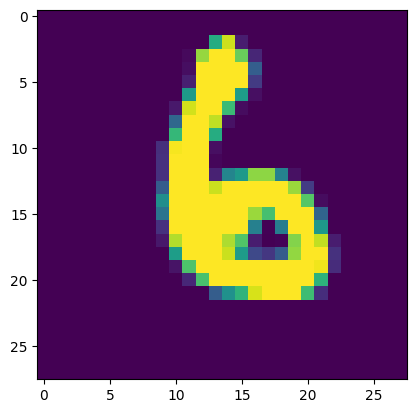

In [4]:
plt.imshow(x_train[810])

In [6]:
# PreProcess The Data
def pre_process(X):
    X = X/255.0 # normalize 
    X = X.reshape((len(X), 784)) #Flatten
    return X

In [7]:
x_train  =  pre_process(x_train)
x_test  =  pre_process(x_test)

In [18]:

# Function to Display The Data 
def display_data(data , height, width, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        ax = plt.subplot(1,10,i+1)
        plt.imshow(data[i].reshape((height,width)))
        plt.gray()        
    plt.suptitle(title)

In [19]:
# Our AutoEncoder 

def AutoEncoder():
    
    # Input Layer
    input_layer = Input(shape=(784,), name="input_layer")
    
    # encoder
    h_1 = Dense(256, activation='relu', name="hidden_layer_1")(input_layer)
    h_2 = Dense(128, activation='relu', name="hidden_layer_2")(h_1)
    h_3 = Dense(64, activation='relu', name="hidden_layer_3")(h_2)
    h_4 = Dense(32, activation='relu', name="hidden_layer_4")(h_3)
    h_5 = Dense(16, activation='relu', name="hidden_layer_5")(h_4)
    h_6 = Dense(8, activation='relu', name="hidden_layer_6")(h_5)
    
    # code layer
    code_layer = Dense(4, activation='relu', name="code_layer")(h_6)
    
    # decoder
    h_7 = Dense(8, activation='relu', name="hidden_layer_7")(code_layer)
    h_8 = Dense(16, activation='relu', name="hidden_layer_8")(h_7)
    h_9 = Dense(32, activation='relu', name="hidden_layer_9")(h_8)
    h_10 = Dense(64, activation='relu', name="hidden_layer_10")(h_9)
    h_11 = Dense(128, activation='relu', name="hidden_layer_11")(h_10)
    h_12 = Dense(256, activation='relu', name="hidden_layer_12")(h_11)
    
    # Output Layer
    output_layer = Dense(784, activation='sigmoid', name="output_layer")(h_12)
    
    model = Model(input_layer, output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    
    return model

In [9]:
# Training The Model
Auto_Encoder = AutoEncoder()
Auto_Encoder.fit(x_train, x_train, epochs=20)   

2025-04-15 11:32:46.316771: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_5 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_6 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code_layer (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_7 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_8 (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_9 (Dense)          │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_10 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_11 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_12 (Dense)         │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 490,564 (1.87 MB)

 Trainable params: 490,564 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 0.2509
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1739
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1671
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1634
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1611
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1598
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1598
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1628
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1572
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1568
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1571
Epoch 12/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1543
Epoch 13/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1519
Epoch 14/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.1500
E

In [10]:
# Get The Decoded Data (The Final Output)
decoded_data = Auto_Encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step 


In [12]:

# Get The Encoder Part of The Model 
encoder = Model(inputs=Auto_Encoder.input, 
                outputs=Auto_Encoder.get_layer("code_layer").output)


In [13]:
# get The Encoded Data (compressed representation of size 2*2)
encoded_data = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [15]:
# encoded_data

In [16]:
# # Display The Final Result
# display_data(x_test, height=28, width=28 , title="original data")
# display_data(encoded_data, height=8, width=8, title="encoded data")
# display_data(decoded_data, height=28, width=28 , title="decoded data")

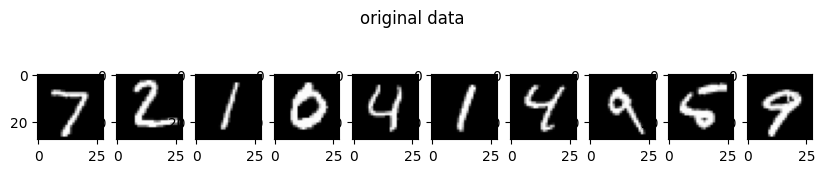

In [20]:
display_data(x_test, height=28, width=28 , title="original data")

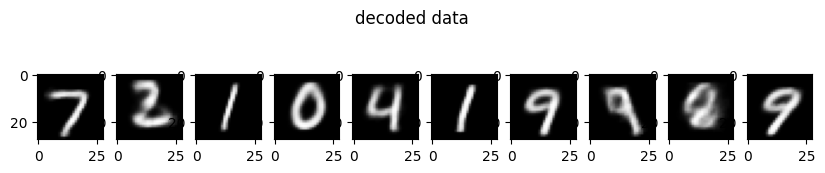

In [21]:
display_data(decoded_data, height=28, width=28 , title="decoded data")